## 10. Part 2 - Visual Weather Systems CNN

### 1. Importing libraries

### 2. Importing data

### 3. Setting up, compiling, and running the model

### 4. Results

#### 1. Importing libraries

In [7]:
import pandas as pd
import numpy as np
import seaborn as sns
import os
import operator
import matplotlib.pyplot as plt
import tensorflow as tf
from keras import Input
from keras.models import Sequential
from keras.models import Model
from keras.layers import Conv1D, Conv2D, Dense, BatchNormalization, Flatten, MaxPooling2D, Activation
from tensorflow.keras.layers import Dense, Dropout
from keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import confusion_matrix, accuracy_score, ConfusionMatrixDisplay

#### 2. Importing data

In [11]:
# Setting the path and printing the list of folders
path = r'C:\Users\Priya\OneDrive\Documents\CareerFoundry\Machine Learning\Achievement 2\Multi-class Weather Dataset'
folders = os.listdir(path)
print(folders)

['Cloudy', 'Rain', 'Shine', 'Sunrise']


In [13]:
# Loading the pictures and rescaling them to 250x250pixels

datagenerator = ImageDataGenerator(rescale=1/255, validation_split=0.2)
train_generator = datagenerator.flow_from_directory(
    path,
    target_size=(250 , 250),
    batch_size=32,
    subset='training',
)

test_generator = datagenerator.flow_from_directory(
    path,
    target_size=(250 , 250),
    batch_size=32,
    subset='validation',
)

Found 901 images belonging to 4 classes.
Found 224 images belonging to 4 classes.


#### 3. Setting up, compiling, and running the model

In [15]:
# This is a CNN to categorize the weather images

inputs = Input(shape=(250, 250, 3))

x = Conv2D(32, (5,5), activation = 'relu')(inputs)
x = MaxPooling2D(3,3)(x)
x = Conv2D(64, (5,5) , activation = 'relu')(x)
x = MaxPooling2D((3,3))(x)
x = Conv2D(128 , (5,5) , activation = 'relu')(x)
x = MaxPooling2D(3,3)(x)
x = Flatten()(x)
x = Dropout(0.5, seed = 5)(x)
x = Dense(128 , activation = 'relu')(x)

outputs = Dense(4, activation = 'softmax')(x)

model:Model = Model(inputs=inputs, outputs=outputs)

In [26]:
# Compiling and running the model

model.compile(optimizer="Adam", loss="mean_squared_error", metrics=["accuracy"])
model.fit(
    train_generator, 
    epochs = 8,
    steps_per_epoch = train_generator.n // train_generator.batch_size,
    validation_data = test_generator,
    validation_steps = test_generator.n // test_generator.batch_size,
)

Epoch 1/8
28/28 ━━━━━━━━━━━━━━━━━━━━ 47s 2s/step - accuracy: 0.8964 - loss: 0.0380 - val_accuracy: 0.8214 - val_loss: 0.0703
Epoch 2/8
28/28 ━━━━━━━━━━━━━━━━━━━━ 5s 162ms/step - accuracy: 0.9688 - loss: 0.0192 - val_accuracy: 0.8348 - val_loss: 0.0639
Epoch 3/8
28/28 ━━━━━━━━━━━━━━━━━━━━ 50s 2s/step - accuracy: 0.9344 - loss: 0.0257 - val_accuracy: 0.8527 - val_loss: 0.0547
Epoch 4/8
28/28 ━━━━━━━━━━━━━━━━━━━━ 7s 202ms/step - accuracy: 0.9688 - loss: 0.0124 - val_accuracy: 0.8661 - val_loss: 0.0511
Epoch 5/8
28/28 ━━━━━━━━━━━━━━━━━━━━ 45s 2s/step - accuracy: 0.9333 - loss: 0.0273 - val_accuracy: 0.7634 - val_loss: 0.1023
Epoch 6/8
28/28 ━━━━━━━━━━━━━━━━━━━━ 5s 141ms/step - accuracy: 0.8438 - loss: 0.0557 - val_accuracy: 0.7500 - val_loss: 0.1133
Epoch 7/8
28/28 ━━━━━━━━━━━━━━━━━━━━ 44s 2s/step - accuracy: 0.9118 - loss: 0.0344 - val_accuracy: 0.8795 - val_loss: 0.0526
Epoch 8/8
28/28 ━━━━━━━━━━━━━━━━━━━━ 6s 213ms/step - accuracy: 1.0000 - loss: 2.3294e-04 - val_accuracy: 0.8705 - val_l

#### 4. Results

In [28]:
results = pd.DataFrame(model.history.history)

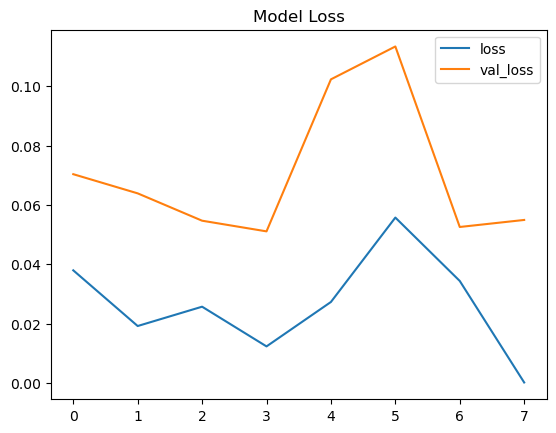

In [30]:
results[['loss','val_loss']].plot(title='Model Loss')
plt.savefig('./loss.png')

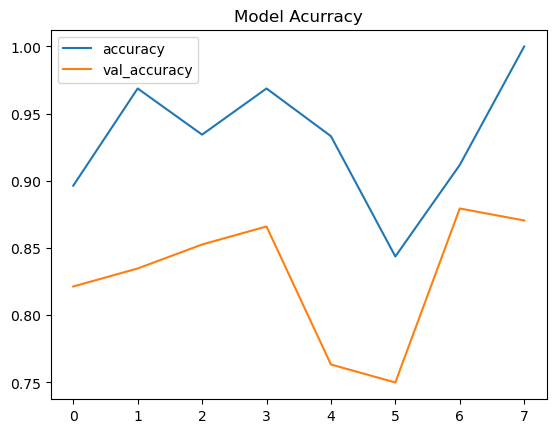

In [32]:
results[['accuracy','val_accuracy']].plot(title='Model Acurracy')
plt.savefig('./accuracy.png')

In [34]:
# Print the accuracy and loss
print("Accuracy: {}, Val_Accuracy: {}".format(results['accuracy'].iloc[-1], results['val_accuracy'].iloc[-1]))
print("Loss: {}, Val_Loss: {}".format(results['loss'].iloc[-1], results['val_loss'].iloc[-1]))

Accuracy: 1.0, Val_Accuracy: 0.8705357313156128
Loss: 0.0002329361450392753, Val_Loss: 0.0549425445497036


11/11 ━━━━━━━━━━━━━━━━━━━━ 4s 352ms/step


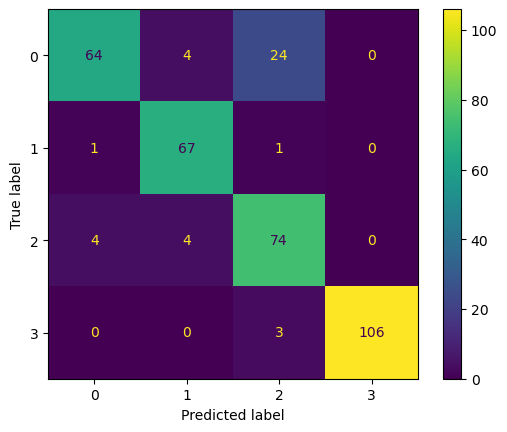

In [36]:
# Collect n batches of images and displaying the confusion matrix for them

class_names = ['Cloudy', 'Rain', 'Shine', 'Sunrise']
n = 10

image_batch, classes_batch = next(test_generator)

for batch in range(n):
    temp = next(test_generator)
    image_batch = np.concatenate((image_batch, temp[0]))
    classes_batch = np.concatenate((classes_batch, temp[1]))

classes_batch = classes_batch
y_predict = model.predict(image_batch)

# Confusion matrix for training data
cm = confusion_matrix(y_pred = [np.argmax(x) for x in y_predict], y_true = [np.argmax(x) for x in classes_batch])
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()

In [38]:
#This function will display a number of random images as well as the predictions for the type of weather

def predict_one(model, num_images = None):  
    image_batch, classes_batch = next(test_generator)
    predicted_batch = model.predict(image_batch)
    for k in range(0,image_batch.shape[0] if num_images is None else num_images):
        image = image_batch[k]
        real_class = class_names[np.argmax(classes_batch[k])]
        predicted_class = class_names[np.argmax(predicted_batch[k])]
        value_predicted = predicted_batch[k]
        isTrue = (real_class == predicted_class)
        plt.figure(k)
        plt.title(str("Correct Prediction" if isTrue else "Incorrect Prediction") + ' - class: ' + real_class + ' - ' + 'predicted: ' + predicted_class + str(value_predicted))
        plt.axis('off')
        plt.savefig('./' + real_class + '_' + predicted_class + '_' + str(value_predicted) + '.png')
        plt.imshow(image)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 474ms/step


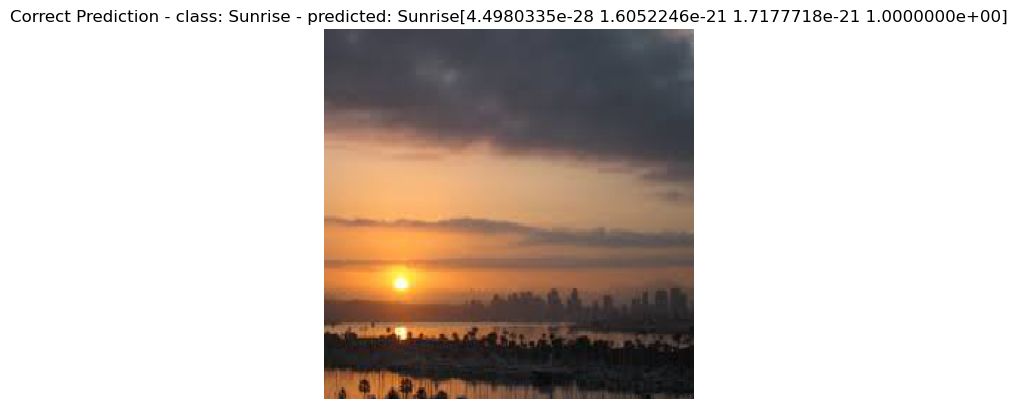

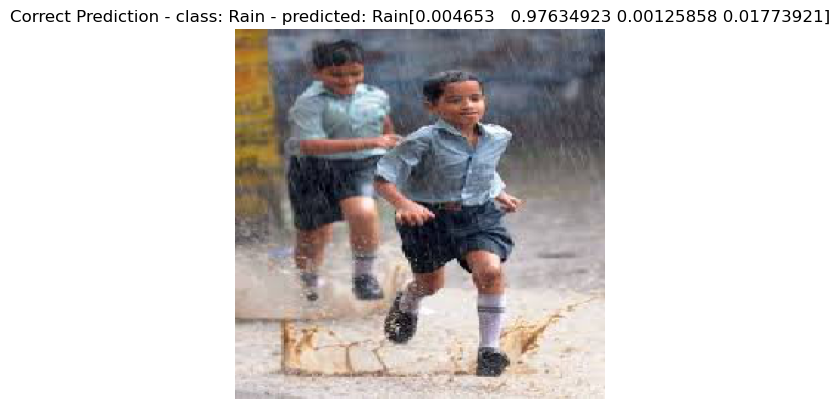

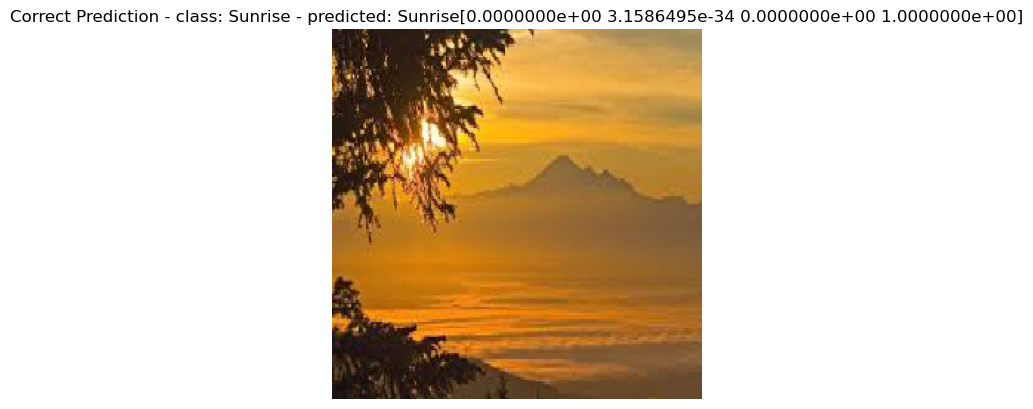

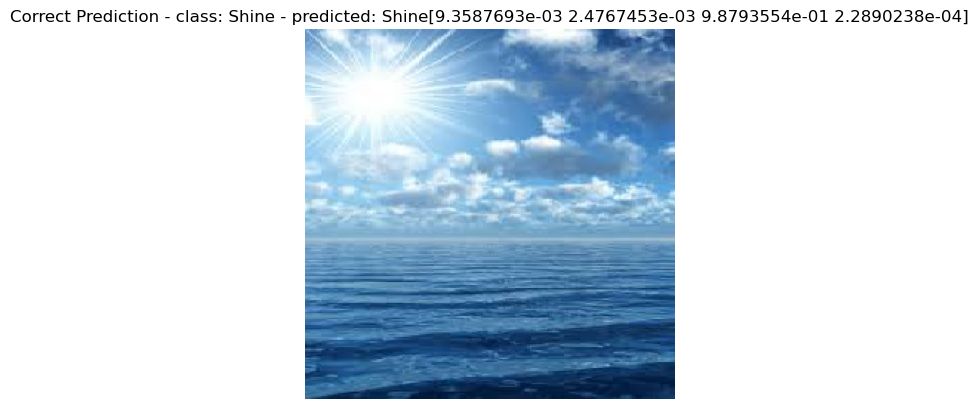

In [40]:
predict_one(model, 4)